In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#Year range: 2011-2023
happiness = pd.read_csv('files/complete_happiness_ONS.csv')
#happiness = happiness[happiness['Time'] == '2022-23']
happiness = happiness[happiness['MeasureOfWellbeing'] == 'Happiness']
happiness = happiness[happiness['Estimate'] == 'Average (mean)']
happiness["Time"] = happiness["Time"].str[:4]
happiness = happiness.drop(labels=['Data marking','yyyy-yy','Lower limit', 'Upper limit','MeasureOfWellbeing','measure-of-wellbeing','wellbeing-estimate'], axis=1)
happiness = happiness.rename(mapper={'v4_3':'Happiness','administrative-geography':'Geo Code',"Geography":"Area", "Estimate":"Happiness Estimate"},axis=1)
happiness.head()

,Happiness,Time,Geo Code,Area,Happiness Estimate
75,7.42,2021,E13000002,Outer London,Average (mean)
76,NaN,2015,E13000002,Outer London,Average (mean)
164,7.32,2020,E13000002,Outer London,Average (mean)
165,NaN,2012,E13000002,Outer London,Average (mean)
166,NaN,2018,E13000002,Outer London,Average (mean)


In [3]:
#NOT USING THIS DATASET
#area = pd.read_csv('files/sam ONS.csv')
#area = area.drop(labels=['AREACHECT','AREAIHECT','LAD24NMW', 'AREALHECT', 'ObjectId'],axis=1)
#area = area.rename(mapper={'LAD24CD':'Geo Code', 'LAD24NM':'Geography','AREAEHECT':'Area (in Hect)'}, axis=1)
#area.head()

In [4]:
#pop = pd.read_csv('files/myebtablesuk20112024.csv')
#pop.columns = pop.iloc[0]
#pop = 
#pop = pop.iloc[7:]
#pop = pop.iloc[:, :4]
#pop.columns = ['Geo Code', 'Name', 'Geography', 'Mid-2023 Population']
#pop.head()

In [5]:
#NOT USING THIS DATASET
#fly = pd.read_csv('files/locauthor_flytip_incidents_2012-25.csv',encoding="cp1252")
#fly = fly.iloc[1:]
#fly.columns = fly.iloc[0]
#fly = fly[1:]
#fly = fly[fly['Year']=="2024-25"]
#fly.head()

In [6]:
#Year range: 2003-2023
recycle_rates = pd.read_csv("files/Household-rcycling-borough.csv")
#recycle = recycle[recycle['Year']=="2022/23"]
recycle_rates = recycle_rates.rename({"Code":"Geo Code","Year":"Time"},axis=1)
recycle_rates["Time"] = recycle_rates["Time"].str[:4]
recycle_rates.head()

,Geo Code,Area,Time,Recycling_Rates
0,E09000001,City of London,2003,8
1,E09000002,Barking and Dagenham,2003,5
2,E09000003,Barnet,2003,16
3,E09000004,Bexley,2003,21
4,E09000005,Brent,2003,10


In [7]:
revenue = pd.read_csv("files/Revenue_Outturn_25_RO5only.csv")
revenue1 = revenue.iloc[:,:4]
revenue2 = revenue[["RO5_envrcy_tot_exp"]]
revenue1["Total Recycling Expenditure"] = revenue2
revenue = revenue1
revenue.head()

,year_ending,ONS_code,LA_LGF_code,LA_name,Total Recycling Expenditure
0,202503,CA,CA,Combined Authorities,0.0
1,202503,E06,UA,Unitary Authorities,261229.0
2,202503,E06000001,E0701,Hartlepool UA,2735.0
3,202503,E06000002,E0702,Middlesbrough UA,558.0
4,202503,E06000003,E0703,Redcar & Cleveland UA,3534.0


In [8]:
housing_density = pd.read_csv("files/housing-density-borough.csv")
housing_density = housing_density.drop(["Source", "Population", "Inland_Area _Hectares", "Total_Area_Hectares","Population_per_hectare", "Square_Kilometres"], axis=1)
housing_density = housing_density.rename({"Code":"Geo Code", "Year":"Time", "Name":"Area", "Population_per_square_kilometre":"Pop_Density"}, axis=1)
housing_density["Time"] = housing_density["Time"].astype(str)
housing_density.head()

,Geo Code,Area,Time,Pop_Density
0,E09000001,City of London,1999,2266.2
1,E09000001,City of London,2000,2415.3
2,E09000001,City of London,2001,2534.1
3,E09000001,City of London,2002,2506.9
4,E09000001,City of London,2003,2450.1


In [9]:
income = pd.read_csv("files/Total, weekly-Table 1(in).csv")
income = income.iloc[1:]
income = income.drop(['Code'],axis=1)
income = income.melt(
    id_vars="Area",
    var_name="Year",
    value_name="Income"
)

income['Income'] = (
    pd.to_numeric(income['Income'], errors='coerce')
    .fillna(0)
)
income.columns = ["Area", "Time", "Income"]
income.head()

,Area,Time,Income
0,City of London,2002,0.0
1,Barking and Dagenham,2002,383.3
2,Barnet,2002,427.4
3,Bexley,2002,405.0
4,Brent,2002,368.4


In [10]:
expenditure2011 = pd.read_csv("files/Recycle Expenditure/Revenue_Outturn__RO5__data_2011-12_by_LA_-_Revised_28-Nov-2013.xls - RO5 LA Data 2011-12 (3).csv")
expenditure2011 = pd.concat([expenditure2011.iloc[13:,:2], expenditure2011.iloc[13:, 139], expenditure2011.iloc[13:, 151]],axis=1)
expenditure2011["Time"] = 2011
expenditure2011.columns = ["Geo Code", "Area", "Waste Collection: Total Cost", "Recycling: Total Cost", "Time"]
expenditure2011.head()

,Geo Code,Area,Waste Collection: Total Cost,Recycling: Total Cost,Time
13,E0101,Bath & North East Somerset UA,"3,119","3,972",2011
14,E0102,Bristol UA,"4,598","7,559",2011
15,E0103,South Gloucestershire UA,"2,062","15,100",2011
16,E0104,North Somerset UA,"5,601",954,2011
17,E0201,Luton UA,"2,701","1,532",2011


In [11]:
expenditure2012 = pd.read_csv("files/Recycle Expenditure/Revenue_Outturn__RO5__data_2012-13_by_LA__Revised__-_18-Feb-2014.xls - RO5 LA Data 2012-13 (3).csv")
expenditure2012 = pd.concat([expenditure2012.iloc[13:,:2], expenditure2012.iloc[13:, 147], expenditure2012.iloc[13:, 159]],axis=1)
expenditure2012["Time"] = 2012
expenditure2012.columns = ["Geo Code", "Area", "Waste Collection: Total Cost", "Recycling: Total Cost", "Time"]
expenditure2012.head()

,Geo Code,Area,Waste Collection: Total Cost,Recycling: Total Cost,Time
13,E0101,Bath & North East Somerset UA,"2,787","4,011",2012
14,E0102,Bristol UA,"3,419","5,868",2012
15,E0103,South Gloucestershire UA,"1,823","15,123",2012
16,E0104,North Somerset UA,"7,037",0,2012
17,E0201,Luton UA,"2,498","1,512",2012


In [12]:
expenditure2013 = pd.read_csv("files/Recycle Expenditure/Revenue_Outturn__RO5__data_2013-14_by_LA.xls - RO5 LA Data 2013-14 (3).csv")
expenditure2013 = pd.concat([expenditure2013.iloc[13:,:2], expenditure2013.iloc[13:, 147], expenditure2013.iloc[13:, 159]],axis=1)
expenditure2013["Time"] = 2013
expenditure2013.columns = ["Geo Code", "Area", "Waste Collection: Total Cost", "Recycling: Total Cost", "Time"]
expenditure2013.head()

,Geo Code,Area,Waste Collection: Total Cost,Recycling: Total Cost,Time
13,E0101,Bath & North East Somerset UA,"2,761","4,168",2013
14,E0102,Bristol UA,"1,588","2,805",2013
15,E0103,South Gloucestershire UA,"8,556","3,689",2013
16,E0104,North Somerset UA,"5,488",127,2013
17,E0201,Luton UA,"2,699","1,294",2013


In [13]:
expenditure2014 = pd.read_csv("files/Recycle Expenditure/Revenue_Outturn__RO5__data_2014-15_by_LA_-_02-Feb-2016.xls - RO5 LA Data 2014-15 (3).csv")
expenditure2014 = pd.concat([expenditure2014.iloc[13:,1:3], expenditure2014.iloc[13:, 76], expenditure2014.iloc[13:, 82]],axis=1)
expenditure2014["Time"] = 2014
expenditure2014.columns = ["Geo Code", "Area", "Waste Collection: Total Cost", "Recycling: Total Cost", "Time"]
expenditure2014.head()

,Geo Code,Area,Waste Collection: Total Cost,Recycling: Total Cost,Time
13,E06000022,Bath & North East Somerset UA,"2,449","3,898",2014
14,E06000023,Bristol UA,"13,028","1,303",2014
15,E06000025,South Gloucestershire UA,"8,558","3,332",2014
16,E06000024,North Somerset UA,"5,200",212,2014
17,E06000032,Luton UA,"2,981","1,322",2014


In [14]:
expenditure2016 = pd.read_csv("files/Recycle Expenditure/RO5_2016-17_data_by_LA.xlsx - RO5 LA Data 2016-17.csv")
expenditure2016 = pd.concat([expenditure2016.iloc[6:,1:3], expenditure2016.iloc[6:, 256], expenditure2016.iloc[6:, 277]],axis=1)
expenditure2016["Time"] = 2016
expenditure2016.columns = ["Geo Code", "Area", "Waste Collection: Total Cost", "Recycling: Total Cost", "Time"]
expenditure2016.head()

,Geo Code,Area,Waste Collection: Total Cost,Recycling: Total Cost,Time
6,E06000022,Bath & North East Somerset UA,"2,953","3,957",2016
7,E06000023,Bristol UA,"7,785","9,674",2016
8,E06000025,South Gloucestershire UA,"7,831","3,002",2016
9,E06000024,North Somerset UA,"4,739",192,2016
10,E06000032,Luton UA,"2,787","1,266",2016


In [15]:
expenditure2017 = pd.read_csv("files/Recycle Expenditure/RO5_2017-18_data_by_LA_-_revised (2) - RO5_LA_Data_2017-18.csv")
expenditure2017 = pd.concat([expenditure2017.iloc[4:,1:3], expenditure2017.iloc[4:, 256], expenditure2017.iloc[4:, 277]],axis=1)
expenditure2017["Time"] = 2017
expenditure2017.columns = ["Geo Code", "Area", "Waste Collection: Total Cost", "Recycling: Total Cost", "Time"]
expenditure2017.head()

,Geo Code,Area,Waste Collection: Total Cost,Recycling: Total Cost,Time
4,E06000022,Bath & North East Somerset UA,"3,147","6,623",2017
5,E06000023,Bristol UA,"7,632","10,359",2017
6,E06000025,South Gloucestershire UA,"8,566","3,316",2017
7,E06000024,North Somerset UA,"5,048",129,2017
8,E06000032,Luton UA,"2,792","1,234",2017


In [16]:
expenditure2018 = pd.read_csv("files/Recycle Expenditure/RO5_2018-19_data_by_LA - RO5_LA_Data_2018-19.csv")
expenditure2018 = pd.concat([expenditure2018.iloc[6:,1:3], expenditure2018.iloc[6:, 256], expenditure2018.iloc[6:, 277]],axis=1)
expenditure2018["Time"] = 2018
expenditure2018.columns = ["Geo Code", "Area", "Waste Collection: Total Cost", "Recycling: Total Cost", "Time"]
expenditure2018.head()

,Geo Code,Area,Waste Collection: Total Cost,Recycling: Total Cost,Time
6,E06000022,Bath & North East Somerset UA,"2,980","5,699",2018
7,E06000023,Bristol UA,"8,145","10,265",2018
8,E06000025,South Gloucestershire UA,"8,789","3,359",2018
9,E06000024,North Somerset UA,"6,266",188,2018
10,E06000032,Luton UA,945,"1,974",2018


In [17]:
expenditure2019 = pd.read_csv("files/Recycle Expenditure/RO5_2019-20_data_by_LA - RO5_LA_Data_2019-20.csv")
expenditure2019 = pd.concat([expenditure2019.iloc[6:,1:3], expenditure2019.iloc[6:, 256], expenditure2019.iloc[6:, 284]],axis=1)
expenditure2019["Time"] = 2019
expenditure2019.columns = ["Geo Code", "Area", "Waste Collection: Total Cost", "Recycling: Total Cost", "Time"]
expenditure2019.head()

,Geo Code,Area,Waste Collection: Total Cost,Recycling: Total Cost,Time
6,E06000022,Bath & North East Somerset UA,"2,882","6,437",2019
7,E06000023,Bristol UA,"5,593","10,839",2019
8,E06000025,South Gloucestershire UA,"2,387","3,501",2019
9,E06000024,North Somerset UA,"1,016",182,2019
10,E06000032,Luton UA,"2,987","1,746",2019


In [18]:
expenditure2020 = pd.read_csv("files/Recycle Expenditure/RO5_2020-21_data_by_LA_March_2025 - RO5_LA_Data_2020-21.csv")
expenditure2020 = pd.concat([expenditure2020.iloc[6:,1:3], expenditure2020.iloc[6:, 263], expenditure2020.iloc[6:, 284]],axis=1)
expenditure2020["Time"] = 2020
expenditure2020.columns = ["Geo Code", "Area", "Waste Collection: Total Cost", "Recycling: Total Cost", "Time"]
expenditure2020.head()

,Geo Code,Area,Waste Collection: Total Cost,Recycling: Total Cost,Time
6,E06000022,Bath & North East Somerset UA,"3,284","8,596",2020
7,E06000023,Bristol UA,"9,590","11,443",2020
8,E06000025,South Gloucestershire UA,"8,227","3,480",2020
9,E06000024,North Somerset UA,-271,341,2020
10,E06000032,Luton UA,"2,359","1,612",2020


In [19]:
expenditure2021 = pd.read_csv("files/Recycle Expenditure/RO5_2021-22_data_by_LA_Live - RO5_LA_Data_2021-22.csv")
expenditure2021 = pd.concat([expenditure2021.iloc[11:,1:3], expenditure2021.iloc[11:, 264], expenditure2021.iloc[11:, 285]],axis=1)
expenditure2021["Time"] = 2021
expenditure2021.columns = ["Geo Code", "Area", "Waste Collection: Total Cost", "Recycling: Total Cost", "Time"]
expenditure2021.head()

,Geo Code,Area,Waste Collection: Total Cost,Recycling: Total Cost,Time
11,E07000223,Adur,"1,237",-703,2021
12,E07000026,Allerdale,"2,010",629,2021
13,E07000032,Amber Valley,"1,404",714,2021
14,E07000224,Arun,"2,033","1,010",2021
15,E07000170,Ashfield,946,"1,330",2021


In [20]:
expenditure2022 = pd.read_csv("files/Recycle Expenditure/RO5_2022-23_data_by_LA - RO5_LA_Data_2022-23.csv")
expenditure2022 = pd.concat([expenditure2022.iloc[11:,1:3], expenditure2022.iloc[11:, 266], expenditure2022.iloc[11:, 287]],axis=1)
expenditure2022["Time"] = 2022
expenditure2022.columns = ["Geo Code", "Area", "Waste Collection: Total Cost", "Recycling: Total Cost", "Time"]
expenditure2022.head()

,Geo Code,Area,Waste Collection: Total Cost,Recycling: Total Cost,Time
11,E07000223,Adur,574,443,2022
12,E07000026,Allerdale,"2,336",623,2022
13,E07000032,Amber Valley,"1,487",775,2022
14,E07000224,Arun,"2,270","1,231",2022
15,E07000170,Ashfield,959,"1,653",2022


In [21]:
expenditure2023 = pd.read_csv("files/Recycle Expenditure/RO5_2023-24_data_by_LA - RO5_LA_Data_2023-24.csv")
expenditure2023 = pd.concat([expenditure2023.iloc[11:,1:3], expenditure2023.iloc[11:, 266], expenditure2023.iloc[11:, 287]],axis=1)
expenditure2023["Time"] = 2023
expenditure2023.columns = ["Geo Code", "Area", "Waste Collection: Total Cost", "Recycling: Total Cost", "Time"]
expenditure2023.head()

,Geo Code,Area,Waste Collection: Total Cost,Recycling: Total Cost,Time
11,E07000223,Adur,553,322,2023
12,E07000032,Amber Valley,"1,609","1,068",2023
13,E07000224,Arun,"1,520","1,874",2023
14,E07000170,Ashfield,970,"1,974",2023
15,E07000105,Ashford,"2,967",0,2023


In [22]:
expenditure2011_13 = pd.concat([expenditure2011, expenditure2012, expenditure2013])
expenditure2011_13["Time"] = expenditure2011_13["Time"].astype("string")
split = expenditure2011_13["Geo Code"].str.split("E0") # CONVERTS TO ONS GEOCODE MAYBE CORRECTLY
split = split.str.get(1)
split = pd.to_numeric(split, errors='coerce').astype('Int64')
split = split - 79
split = split.astype(str)
split = "E090000"+split
expenditure2011_13["Geo Code"] = split
expenditure2011_13.head()

,Geo Code,Area,Waste Collection: Total Cost,Recycling: Total Cost,Time
13,E09000022,Bath & North East Somerset UA,"3,119","3,972",2011
14,E09000023,Bristol UA,"4,598","7,559",2011
15,E09000024,South Gloucestershire UA,"2,062","15,100",2011
16,E09000025,North Somerset UA,"5,601",954,2011
17,E090000122,Luton UA,"2,701","1,532",2011


In [23]:
expenditure2014_23 = pd.concat([expenditure2014, expenditure2016, expenditure2017,expenditure2018,expenditure2019,expenditure2020,expenditure2021,expenditure2022,expenditure2023])
expenditure2014_23["Time"] = expenditure2014_23["Time"].astype("string")
expenditure2014_23.head()

,Geo Code,Area,Waste Collection: Total Cost,Recycling: Total Cost,Time
13,E06000022,Bath & North East Somerset UA,"2,449","3,898",2014
14,E06000023,Bristol UA,"13,028","1,303",2014
15,E06000025,South Gloucestershire UA,"8,558","3,332",2014
16,E06000024,North Somerset UA,"5,200",212,2014
17,E06000032,Luton UA,"2,981","1,322",2014


In [24]:
#full_table = happiness.merge(recycle_rates)
full_table0 = happiness.merge(recycle_rates).merge(housing_density).merge(income)
#full_table0["Time"] = full_table0["Time"].astype("string")
full_table1 = pd.merge(full_table0,
                         expenditure2011_13,
                         on=["Time", "Geo Code"],
                         how="left") #so that it doesn't delete the rows of other years !!!
full_table2 = pd.merge(full_table1,
                       expenditure2014_23,
                       on=["Time", "Geo Code"],
                       how="left")
full_table2['Waste Collection: Total Cost'] = full_table2['Waste Collection: Total Cost_x'].combine_first(
                                              full_table2['Waste Collection: Total Cost_y'])
full_table2['Recycling: Total Cost'] = full_table2['Recycling: Total Cost_x'].combine_first(
                                       full_table2['Recycling: Total Cost_y'])

full_table2 = full_table2.drop(columns=['Waste Collection: Total Cost_x', 
                                        'Waste Collection: Total Cost_y',
                                        'Recycling: Total Cost_x', 
                                        'Recycling: Total Cost_y',
                                        'Area_y', 'Area'])
full_table2 = full_table2.rename({"Area_x":"Area"},axis=1)

full_table2['Waste Collection: Total Cost'] = pd.to_numeric(
    full_table2['Waste Collection: Total Cost'].astype(str).str.replace(',', ''), 
    errors='coerce')

full_table2['Recycling: Total Cost'] = pd.to_numeric(
    full_table2['Recycling: Total Cost'].astype(str).str.replace(',', ''), 
    errors='coerce')

full_table2 = full_table2.sort_values("Time")



full_table2.head()
# full_table2.to_csv('full_table2.csv', 
#                     index=False,
#                     encoding='utf-8')

,Happiness,Time,Geo Code,Area,Happiness Estimate,Recycling_Rates,Pop_Density,Income,Waste Collection: Total Cost,Recycling: Total Cost
262,7.25,2011,E09000028,Southwark,Average (mean),27,10025.7,530.5,NaN,NaN
27,7.26,2011,E09000003,Barnet,Average (mean),34,4122.9,498.3,NaN,NaN
213,7.11,2011,E09000023,Lewisham,Average (mean),17,7895.6,473.2,4598.0,7559.0
89,7.27,2011,E09000021,Kingston upon Thames,Average (mean),47,4306.6,579.8,NaN,NaN
282,7.39,2011,E09000018,Hounslow,Average (mean),35,4561.3,473.2,NaN,NaN


In [25]:
#full_table0 = pd.merge(left = happiness, right = recycle, left_on="Geo Code", right_on="Code")
#full_table1 = pd.merge(left = full_table0, right = revenue, left_on="Geo Code", right_on="ONS_code")
#full_table2 = pd.merge(left= full_table1, right = pop, left_on="Geo Code", right_on="Geo Code")

#full_table = full_table2.drop(labels=['Time','measure-of-wellbeing','Estimate','Code', 'Area', 'Year','ONS_code','LA_LGF_code','LA_name', 'Name', 'Geography_y'], axis=1)

#full_table["Mid-2023 Population"] = full_table["Mid-2023 Population"].str.replace(pat=',', repl='',regex=False)
#full_table["Mid-2023 Population"] = full_table["Mid-2023 Population"].astype('float')
#full_table["Expenditure_per_capita"] = full_table["Total Recycling Expenditure"] / full_table["Mid-2023 Population"]
#full_table.head(10)

In [26]:
formula_string = "Recycling_Rates ~ Happiness"
min_model = sm.formula.ols(formula = formula_string, data = full_table2)
min_model_fitted = min_model.fit()

print(min_model_fitted.summary())

                            OLS Regression Results                            
Dep. Variable:        Recycling_Rates   R-squared:                       0.027
Model:                            OLS   Adj. R-squared:                  0.024
Method:                 Least Squares   F-statistic:                     8.270
Date:                Thu, 02 Apr 2026   Prob (F-statistic):            0.00432
Time:                        15:54:00   Log-Likelihood:                -1095.7
No. Observations:                 300   AIC:                             2195.
Df Residuals:                     298   BIC:                             2203.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -24.5886     20.533     -1.198      0.2

In [27]:
formula_string = """
Recycling_Rates ~ Happiness + Pop_Density + Income + 
                  Q('Waste Collection: Total Cost') + 
                  Q('Recycling: Total Cost')
"""
max_model = sm.formula.ols(formula = formula_string, data = full_table2)
max_model_fitted = max_model.fit()

print(max_model_fitted.summary())

                            OLS Regression Results                            
Dep. Variable:        Recycling_Rates   R-squared:                       0.411
Model:                            OLS   Adj. R-squared:                  0.397
Method:                 Least Squares   F-statistic:                     28.37
Date:                Thu, 02 Apr 2026   Prob (F-statistic):           9.21e-22
Time:                        15:54:00   Log-Likelihood:                -713.52
No. Observations:                 209   AIC:                             1439.
Df Residuals:                     203   BIC:                             1459.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

In [28]:
# Robustness check 

# Sets-up the Happiness DF so that there's only the column of Happinness_Inequality
happiness2 = pd.read_csv('files/complete_happiness_ONS.csv')
happiness2 = happiness2[happiness2['MeasureOfWellbeing'] == 'Happiness']
happiness2 = happiness2[happiness2['Estimate'] == 'Average (mean)']
happiness2 = happiness2.rename(mapper={'v4_3':'Happiness','administrative-geography':'Geo Code',"Geography":"Area", "Estimate":"Happiness Estimate"},axis=1)


happiness2 = happiness2.dropna(subset=["Happiness"])

happiness2['Lower limit'] = pd.to_numeric(
    happiness2['Lower limit'])
happiness2['Upper limit'] = pd.to_numeric(
    happiness2['Upper limit'])

happiness2["Time"] = happiness2["Time"].str[:4]
happiness2["Happiness_Range"] = happiness2["Upper limit"] - happiness2["Lower limit"]
happiness2 = happiness2.drop(labels=['Data marking','yyyy-yy','Lower limit', 'Upper limit','MeasureOfWellbeing','measure-of-wellbeing','wellbeing-estimate', 'Happiness', 'Happiness Estimate'], axis=1)

# Merges like before (CODE IS COPIED)
robust_table0 = happiness2.merge(recycle_rates).merge(housing_density).merge(income)

robust_table1 = pd.merge(robust_table0,
                         expenditure2011_13,
                         on=["Time", "Geo Code"],
                         how="left") #so that it doesn't delete the rows of other years !!!
robust_table2 = pd.merge(robust_table1,
                       expenditure2014_23,
                       on=["Time", "Geo Code"],
                       how="left")
robust_table2['Waste Collection: Total Cost'] = robust_table2['Waste Collection: Total Cost_x'].combine_first(
                                              robust_table2['Waste Collection: Total Cost_y'])
robust_table2['Recycling: Total Cost'] = robust_table2['Recycling: Total Cost_x'].combine_first(
                                       robust_table2['Recycling: Total Cost_y'])

robust_table2 = robust_table2.drop(columns=['Waste Collection: Total Cost_x', 
                                        'Waste Collection: Total Cost_y',
                                        'Recycling: Total Cost_x', 
                                        'Recycling: Total Cost_y',
                                        'Area_y', 'Area'])
robust_table2 = robust_table2.rename({"Area_x":"Area"},axis=1)

robust_table2['Waste Collection: Total Cost'] = pd.to_numeric(
    robust_table2['Waste Collection: Total Cost'].astype(str).str.replace(',', ''), 
    errors='coerce')

robust_table2['Recycling: Total Cost'] = pd.to_numeric(
    robust_table2['Recycling: Total Cost'].astype(str).str.replace(',', ''), 
    errors='coerce')

robust_table2 = robust_table2.sort_values("Time")

# Robest Max Model Check

formula_string = """
Recycling_Rates ~ Happiness_Range + Pop_Density + Income + 
                  Q('Waste Collection: Total Cost') + 
                  Q('Recycling: Total Cost')
"""
robust_max_model = sm.formula.ols(formula = formula_string, data = robust_table2)
robust_max_model_fitted = robust_max_model.fit()

print(robust_max_model_fitted.summary())


                            OLS Regression Results                            
Dep. Variable:        Recycling_Rates   R-squared:                       0.415
Model:                            OLS   Adj. R-squared:                  0.400
Method:                 Least Squares   F-statistic:                     28.76
Date:                Thu, 02 Apr 2026   Prob (F-statistic):           5.31e-22
Time:                        15:54:00   Log-Likelihood:                -712.94
No. Observations:                 209   AIC:                             1438.
Df Residuals:                     203   BIC:                             1458.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

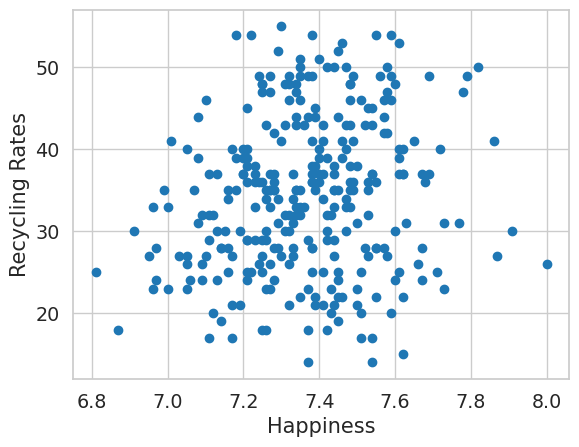

In [33]:
# #y_pred = model_fitted.predict(full_table['Happiness'])

# plt.scatter(full_table2.Happiness, full_table2.Recycling_Rates)
# #plt.plot(full_table['Happiness'], y_pred, color = 'orange')

# plt.xlabel('Happiness')
# plt.ylabel('Recycling Rates')
# plt.show();
# plt.close()

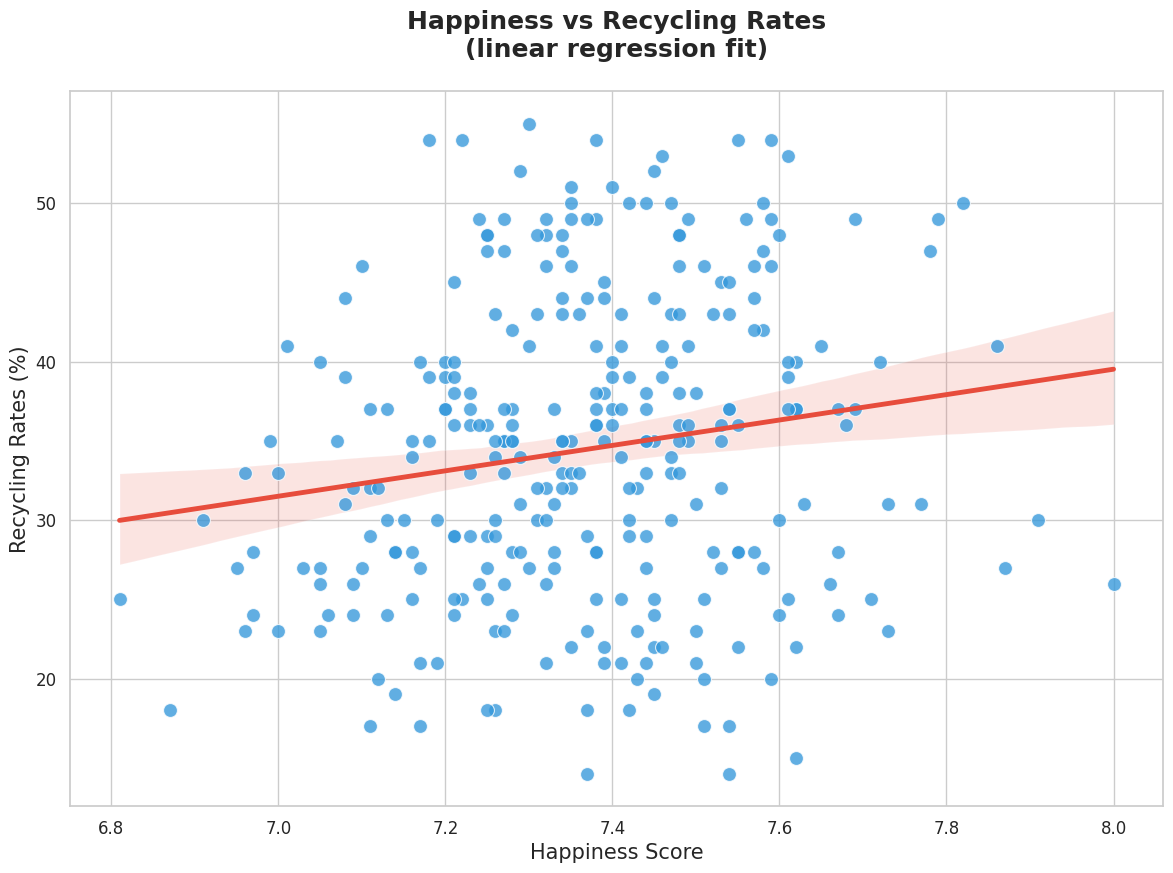

In [57]:
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.3)

plt.figure(figsize=(12, 9))

sns.regplot(
    x='Happiness', 
    y='Recycling_Rates', 
    data=full_table2,
    scatter=False,
    line_kws={'color': '#e74c3c', 'linewidth': 3.5},
    ci=95
)

sns.scatterplot(
    x='Happiness',
    y='Recycling_Rates',
    data=full_table2,
    s=100,
    alpha=0.78,
    edgecolor='white',
    linewidth=0.8,
    color='#3498db'
)

plt.title('Happiness vs Recycling Rates\n(linear regression fit)', 
          fontsize=18, pad=25, fontweight='bold')
plt.xlabel('Happiness Score', fontsize=15)
plt.ylabel('Recycling Rates (%)', fontsize=15)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()

plt.savefig('happiness_vs_recycling.png',dpi=300,bbox_inches='tight')
plt.show()

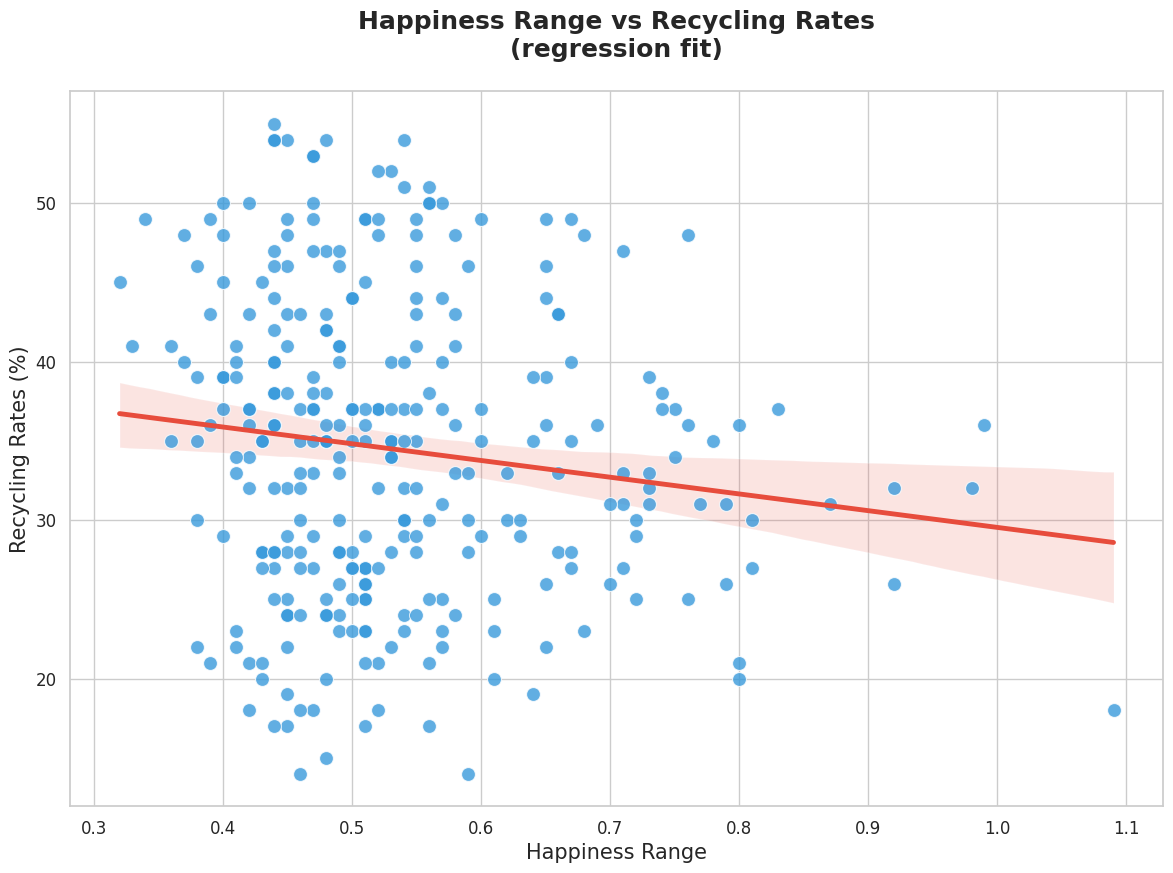

In [59]:
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.3)

plt.figure(figsize=(12, 9))

sns.regplot(
    x='Happiness_Range',
    y='Recycling_Rates',
    data=robust_table2,
    scatter=False,
    line_kws={'color': '#e74c3c', 'linewidth': 3.5},
    ci=95
)

sns.scatterplot(
    x='Happiness_Range',
    y='Recycling_Rates',
    data=robust_table2,
    s=100,  
    alpha=0.78,
    edgecolor='white',
    linewidth=0.8,
    color='#3498db')

plt.title('Happiness Range vs Recycling Rates\n(regression fit)', 
          fontsize=18, pad=25, fontweight='bold')
plt.xlabel('Happiness Range', fontsize=15)
plt.ylabel('Recycling Rates (%)', fontsize=15)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.savefig('happiness_range_vs_recycling.png',dpi=300,bbox_inches='tight')
plt.show()

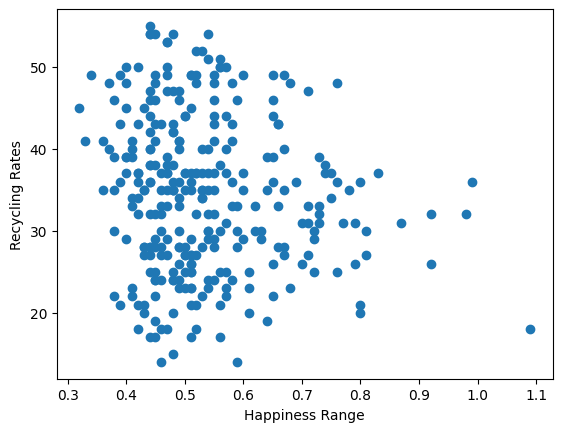

In [194]:
# plt.scatter(robust_table2.Happiness_Range, robust_table2.Recycling_Rates)
# #plt.plot(full_table['Happiness'], y_pred, color = 'orange')

# plt.xlabel('Happiness Range')
# plt.ylabel('Recycling Rates')
# plt.show();

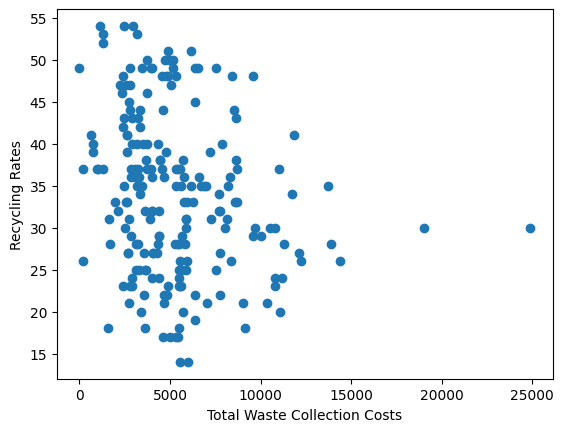

In [182]:
# plt.scatter(full_table2["Waste Collection: Total Cost"], full_table2.Recycling_Rates)
# #plt.plot(full_table['Happiness'], y_pred, color = 'orange')

# plt.xlabel('Total Waste Collection Costs')
# plt.ylabel('Recycling Rates')
# plt.show();

In [ ]:
# plt.scatter(full_table["Expenditure_per_capita"], full_table.Recycling_Rates)
# #plt.plot(full_table['Happiness'], y_pred, color = 'orange')

# plt.xlabel('Expenditure Per Capita')
# plt.ylabel('Recycling Rates')
# plt.show();

In [ ]:
# OLD CODE
# full_table0 = pd.merge(left = happiness, right = recycle, left_on="Geo Code", right_on="Code")
# full_table1 = pd.merge(left = full_table0, right = revenue, left_on="Geo Code", right_on="ONS_code")
# full_table2 = pd.merge(left= full_table1, right = pop, left_on="Geo Code", right_on="Geo Code")

# full_table = full_table2.drop(labels=['Time','measure-of-wellbeing','Estimate','Code', 'Area', 'Year','ONS_code','LA_LGF_code','LA_name', 'Name', 'Geography_y'], axis=1)

# full_table["Mid-2023 Population"] = full_table["Mid-2023 Population"].str.replace(pat=',', repl='',regex=False)
# full_table["Mid-2023 Population"] = full_table["Mid-2023 Population"].astype('float')
# full_table["Expenditure_per_capita"] = full_table["Total Recycling Expenditure"] / full_table["Mid-2023 Population"]
# full_table.head(10)